Catastrophic Forgetting/Interference

Confirming and Visualizing the interference

In [20]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

Setting up Hyperparameters

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 1e-3
batch_size = 64
epochs_per_task = 3
tasks = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]

In [22]:
print(f"Using device: {device}")

Using device: cpu


Dataset Loading and splitting

In [23]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [24]:
train_dataset = datasets.MNIST(root='/home/bukunmi/ml-journey/datasets/data', train=True, download=True, transform=mnist_transform)
test_dataset = datasets.MNIST(root='/home/bukunmi/ml-journey/datasets/data', train=False, download=True, transform=mnist_transform)

In [25]:
# Filter by Digits

def filter_by_digits(dataset, digits):
    indices = [i for i, (_, label) in enumerate(dataset) if label in digits]
    return Subset(dataset, indices)

In [26]:
# Get split MNIST datasets for each task
def get_split_mnist_datasets(tasks_digits):
    train_subset = filter_by_digits(train_dataset, tasks_digits)
    test_subset = filter_by_digits(test_dataset, tasks_digits)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

Defining the MNIST MLP

In [27]:
class MNISTMLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=400, output_size=10):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.fc(x)

Instantiate Model, optimizer, criterion and task loaders

In [28]:
model = MNISTMLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [29]:
task_loaders = [get_split_mnist_datasets(task) for task in tasks]

Training Init

In [30]:
accuracy_history = np.zeros((len(tasks), len(tasks)))

In [31]:
# Evaluation Function
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return (correct / total) * 100 if total > 0 else 0.0

In [32]:
# Training Loop
for train_task_idx, (train_loader, test_loader) in enumerate(task_loaders):
    print(f"\n--- Training on Task {train_task_idx + 1} -- (Digits: {tasks[train_task_idx]})")
    for epoch in range(epochs_per_task):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch + 1}/{epochs_per_task} ----- Loss: {running_loss / len(train_loader):.4f}")
    print(f"--- Evaluating after Task {train_task_idx + 1} ---")
    for eval_task_idx, (_, test_loader) in enumerate(task_loaders):
        acc = evaluate(model, test_loader)
        accuracy_history[eval_task_idx, train_task_idx] = acc
        print(f"  Accuracy on Task {eval_task_idx + 1} (Digits {tasks[eval_task_idx]}): {acc:.2f}%")


--- Training on Task 1 -- (Digits: (0, 1))
Epoch 1/3 ----- Loss: 0.0396
Epoch 2/3 ----- Loss: 0.0032
Epoch 3/3 ----- Loss: 0.0019
--- Evaluating after Task 1 ---
  Accuracy on Task 1 (Digits (0, 1)): 99.95%
  Accuracy on Task 2 (Digits (2, 3)): 0.00%
  Accuracy on Task 3 (Digits (4, 5)): 0.00%
  Accuracy on Task 4 (Digits (6, 7)): 0.00%
  Accuracy on Task 5 (Digits (8, 9)): 0.00%

--- Training on Task 2 -- (Digits: (2, 3))
Epoch 1/3 ----- Loss: 0.2673
Epoch 2/3 ----- Loss: 0.0373
Epoch 3/3 ----- Loss: 0.0216
--- Evaluating after Task 2 ---
  Accuracy on Task 1 (Digits (0, 1)): 0.00%
  Accuracy on Task 2 (Digits (2, 3)): 99.51%
  Accuracy on Task 3 (Digits (4, 5)): 0.00%
  Accuracy on Task 4 (Digits (6, 7)): 0.00%
  Accuracy on Task 5 (Digits (8, 9)): 0.00%

--- Training on Task 3 -- (Digits: (4, 5))
Epoch 1/3 ----- Loss: 0.4539
Epoch 2/3 ----- Loss: 0.0178
Epoch 3/3 ----- Loss: 0.0096
--- Evaluating after Task 3 ---
  Accuracy on Task 1 (Digits (0, 1)): 0.00%
  Accuracy on Task 2 (Dig

The model is forgetting all previous knowledge.

Plotting the forgetting curve

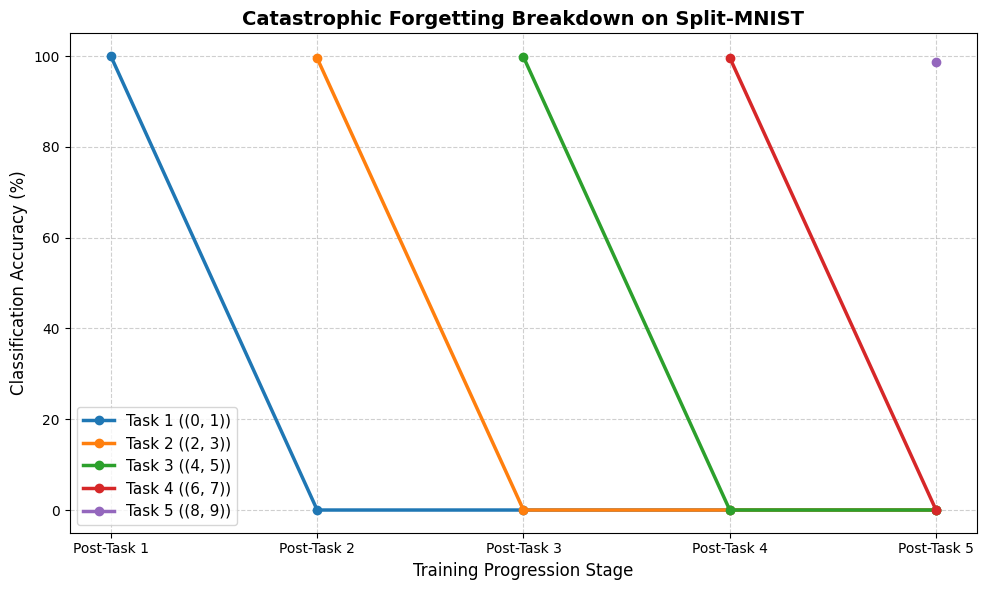

In [33]:
plt.figure(figsize=(10, 6))
x_ticks = [f"Post-Task {i+1}" for i in range(len(tasks))]

for task_idx in range(len(tasks)):
    y_values = accuracy_history[task_idx]
    plt.plot(x_ticks[task_idx:], y_values[task_idx:], marker='o', linewidth=2.5, label=f"Task {task_idx+1} ({tasks[task_idx]})")

plt.title("Catastrophic Forgetting Breakdown on Split-MNIST", fontsize=14, fontweight='bold')
plt.xlabel("Training Progression Stage", fontsize=12)
plt.ylabel("Classification Accuracy (%)", fontsize=12)
plt.ylim(-5, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()